# Sandhead Observational Data Download


In this notebook, data of Sandhead station (49°06'21.225" N, 123°18'12.123" W, Elevation:11.00 m) is downloaded from https://climate.weather.gc.ca/climate_data/hourly_data_e.html?climate_id=1107010.

## Downloading


<details>

<summary>Download Information</summary>
Station Information: SANDHEADS CS	BRITISH COLUMBIA	1107010	6831	71209	WVF	49.11	-123.3	490621225	-1231812123	11	1991	2026	1994	2026	1991	2026	1991	1999

Using command: for year in `seq 1998 2008`;do for month in `seq 1 12`;do wget --content-disposition "https://climate.weather.gc.ca/climate_data/bulk_data_e.html?format=csv&stationID=1706&Year=${year}&Month=${month}&Day=14&timeframe=1&submit= Download+Data" ;done;done for reference. 

Note: to download the hourly data in UTC rather than LTC, please add &time=utc after format=csv in the wget statement

Also note: use UTC instead of 'utc'!

Save to: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2008_2024
</details>


In [ ]:
# Downloading

import os
import requests
import re
import time

def download_climate_data():
    # 参数设置
    station_id = 6831       # 提取自您提供的 Sandheads 站点信息
    start_year = 2008       # 提取自您的目标路径名
    end_year = 2024
    
    # 目标保存路径
    save_dir = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2008_2024"
    
    # 如果目录不存在，则创建它
    os.makedirs(save_dir, exist_ok=True)
    print(f"开始下载数据，保存至: {save_dir}")

    # 循环年份和月份
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            # 构造下载链接 (timeframe=1 表示逐时数据)
            url = (
                f"https://climate.weather.gc.ca/climate_data/bulk_data_e.html?"
                f"format=csv&time=UTC&stationID={station_id}&Year={year}&Month={month}"
                f"&Day=14&timeframe=1&submit=Download+Data"
            )
            
            try:
                # 发送 GET 请求
                response = requests.get(url, timeout=30)
                response.raise_for_status() # 检查是否有 4xx/5xx 错误
                
                # 尝试从 Header 中获取官方提供的文件名 (类似 wget --content-disposition)
                content_disposition = response.headers.get('content-disposition')
                if content_disposition:
                    # 使用正则提取 filename="xxx.csv" 中的文件名
                    fname_match = re.findall('filename="?([^"]+)"?', content_disposition)
                    if fname_match:
                        filename = fname_match[0]
                    else:
                        filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                else:
                    filename = f"Sandheads_Hourly_{year}_{month:02d}.csv"
                    
                filepath = os.path.join(save_dir, filename)
                
                # 将内容写入本地文件
                with open(filepath, 'wb') as f:
                    f.write(response.content)
                    
                print(f"成功下载: {filename}")
                
                # 暂停 1 秒，避免请求过于频繁导致被加拿大环境部服务器封禁 IP
                time.sleep(1) 

            except requests.exceptions.RequestException as e:
                print(f"下载失败 {year}年{month:02d}月: {e}")

    print("所有数据下载完成！")

if __name__ == "__main__":
    download_climate_data()

## Data Inspection


<details>

<summary>Col Names:</summary>

"Longitude (x)","Latitude (y)","Station Name","Climate ID","Date/Time (UTC)","Year","Month","Day","Time (UTC)","Flag","Temp (°C)","Temp Flag","Dew Point Temp (°C)","Dew Point Temp Flag","Rel Hum (%)","Rel Hum Flag","Precip. Amount (mm)","Precip. Amount Flag","Wind Dir (10s deg)","Wind Dir Flag","Wind Spd (km/h)","Wind Spd Flag","Visibility (km)","Visibility Flag","Stn Press (kPa)","Stn Press Flag","Hmdx","Hmdx Flag","Wind Chill","Wind Chill Flag","Weather"

</details>

What we are interested in: "Wind Dir (10s deg)", "Wind Spd (km/h)"

File path and example name: '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2008_2024/en_climate_hourly_BC_1107010_11-2021_P1H.csv'


**Note: wind speed is measured by km/h.**

## Comparison

Recall the HRDPS and CaSR data.

Example path and file names:

<details>
<summary>HRDPS data</summary>

path and example name: '/results/forcing/atmospheric/GEM2.5/operational/ops_y2018m01d01.nc'

Variables: ['atmpres', 'nav_lat', 'nav_lon', 'percentcloud', 'precip', 'qair', 'solar', 'tair', 'therm_rad', 'u_wind', 'v_wind', 'time_counter', 'x', 'y']
</details>

<details>
<summary>CaSR data</summary>

path and example name: '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc' and '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'

Variables: ['rotated_pole', 'CaSR_v3.2_P_UUC_10m', 'time', 'lon', 'lat', 'rlon', 'rlat'] and ['rotated_pole', 'CaSR_v3.2_P_VVC_10m', 'time', 'lon', 'lat', 'rlon', 'rlat']
</details>

**Note: wind speed in CaSR is measured by kns!**

In [ ]:
# Variable Display

import xarray as xr

file_paths = [
    '/results/forcing/atmospheric/GEM2.5/operational/ops_y2018m01d01.nc',
    '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc',
    '/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc'
]

for file in file_paths:
    try:
        ds = xr.open_dataset(file)
        print(f"{file} variables")
        print(list(ds.variables.keys())) 
        print("\n")
        ds.close()
    except Exception as e:
        print(f"unable to access {file}: {e}")

/results/forcing/atmospheric/GEM2.5/operational/ops_y2018m01d01.nc variables
['atmpres', 'nav_lat', 'nav_lon', 'percentcloud', 'precip', 'qair', 'solar', 'tair', 'therm_rad', 'u_wind', 'v_wind', 'time_counter', 'x', 'y']


/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc variables
['rotated_pole', 'CaSR_v3.2_P_UUC_10m', 'time', 'lon', 'lat', 'rlon', 'rlat']


/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc variables
['rotated_pole', 'CaSR_v3.2_P_VVC_10m', 'time', 'lon', 'lat', 'rlon', 'rlat']




In [3]:
# Data Extraction

import xarray as xr
import pandas as pd
import numpy as np
import glob




# 目标位置
target_lat = 49.11
target_lon = -123.3

# 辅助函数：计算两个经纬度之间的地球表面距离（公里）- 用于核对
def haversine_dist(lat1, lon1, lat2, lon2):
    R = 6371.0 # 地球半径(km)
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# 辅助函数：将 u, v 风速分量转换为风的【去向】（Blowing towards）和风速
def uv_to_spd_dir_to(u, v):
    ws = np.sqrt(u**2 + v**2)
    # 去向：0度为向北吹，90度为向东吹
    wd = (90 - np.rad2deg(np.arctan2(v, u))) % 360
    return ws, wd

# 辅助函数：在 2D 经纬度网格中寻找最近点的索引
def find_nearest_2d_index(lat_array, lon_array, t_lat, t_lon):
    # 处理经度可能为 0~360 的情况
    lon_array_adj = np.where(lon_array > 180, lon_array - 360, lon_array)
    dist = (lat_array - t_lat)**2 + (lon_array_adj - t_lon)**2
    return np.unravel_index(np.argmin(dist, axis=None), dist.shape)

print(f"=== 坐标与距离核对 ===")
print(f"目标观测站点位置: Lat = {target_lat}, Lon = {target_lon}")

print("\n1. 处理站点观测数据...")
obs_path_pattern = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2008_2024/*2018*.csv'
obs_files = glob.glob(obs_path_pattern)
df_obs = pd.concat([pd.read_csv(f) for f in obs_files])

df_obs['Time_UTC'] = pd.to_datetime(df_obs['Date/Time (UTC)'])
df_obs = df_obs.set_index('Time_UTC').sort_index()
df_obs = df_obs[~df_obs.index.duplicated(keep='first')]

# 单位转换，并将气象风向(来向)转换为流向(去向)：加 180 度
df_obs['Obs_Spd_ms'] = df_obs['Wind Spd (km/h)'] * (1000 / 3600)
df_obs['Obs_Dir_deg'] = (df_obs['Wind Dir (10s deg)'] * 10 + 180) % 360
obs_final = df_obs[['Obs_Spd_ms', 'Obs_Dir_deg']].copy()

print("\n2. 处理高分辨率数据 (GEM2.5) ...")
high_res_files = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/operational/ops_y2018*.nc'))

if not high_res_files:
    print("未找到 GEM2.5 文件，请检查路径！")
else:
    # 第一步：只用第一个文件来找索引
    with xr.open_dataset(high_res_files[0]) as ds0:
        lat_high = ds0['nav_lat'].values
        lon_high = ds0['nav_lon'].values
        # 调用之前写的 find_nearest_2d_index 和 haversine_dist
        j_high, i_high = find_nearest_2d_index(lat_high, lon_high, target_lat, target_lon)
        
        # 顺便校验下坐标
        actual_lat = lat_high[j_high, i_high]
        actual_lon = lon_high[j_high, i_high]
        actual_lon_adj = actual_lon if actual_lon < 180 else actual_lon - 360
        dist = haversine_dist(target_lat, target_lon, actual_lat, actual_lon_adj)
        print(f" GEM2.5 选定点: Lat = {actual_lat:.4f}, Lon = {actual_lon_adj:.4f}")
        print(f" 距离目标站点: {dist:.2f} km (y={j_high}, x={i_high})")

    # 第二步：循环所有文件，直接暴力提取单点数据
    u_list, v_list, time_list = [], [], []
    
    for f in high_res_files:
        # 使用 engine='netcdf4' 并在用完后自动 close，防止占满句柄
        with xr.open_dataset(f, engine='netcdf4') as ds:
            # 只加载特定 j, i 的值，不碰其他数据
            u_list.extend(ds['u_wind'].isel(y=j_high, x=i_high).values)
            v_list.extend(ds['v_wind'].isel(y=j_high, x=i_high).values)
            time_list.extend(ds['time_counter'].values)
    
    # 将列表转换为 numpy 数组进行风向转换
    u_arr = np.array(u_list)
    v_arr = np.array(v_list)
    spd_high, dir_high = uv_to_spd_dir_to(u_arr, v_arr)
    
    df_high = pd.DataFrame({'High_Spd_ms': spd_high, 'High_Dir_deg': dir_high}, index=time_list)
    df_high.index.name = 'Time_UTC'
    print(" -> GEM2.5 数据提取完成")

print("\n3. 处理低分辨率数据 (RDPS)...")
ds_low_u = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_UUC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))
ds_low_v = xr.open_dataset('/ocean/jqiu/Atmospheric_RDPS/2008_2024_Integrated/Integrated_RDPS_P_VVC_10m_2008_2024.nc').sel(time=slice('2018-01-01', '2018-12-31'))

lat_low = ds_low_u['lat'].values
lon_low = ds_low_u['lon'].values
j_low, i_low = find_nearest_2d_index(lat_low, lon_low, target_lat, target_lon)

# 获取实际坐标并计算距离
actual_lat_low = lat_low[j_low, i_low]
actual_lon_low = lon_low[j_low, i_low]
actual_lon_low_adj = actual_lon_low if actual_lon_low < 180 else actual_lon_low - 360
dist_low = haversine_dist(target_lat, target_lon, actual_lat_low, actual_lon_low_adj)
print(f" -> RDPS 选定点: Lat = {actual_lat_low:.4f}, Lon = {actual_lon_low_adj:.4f}")
print(f" -> 距离目标站点: {dist_low:.2f} km (网格索引: rlat={j_low}, rlon={i_low})")

u_low = ds_low_u['CaSR_v3.2_P_UUC_10m'].isel(rlat=j_low, rlon=i_low).values
v_low = ds_low_v['CaSR_v3.2_P_VVC_10m'].isel(rlat=j_low, rlon=i_low).values

# CaSR 单位：knots → m/s
KTS_TO_MS = 0.514444
u_low = u_low * KTS_TO_MS
v_low = v_low * KTS_TO_MS


time_low = ds_low_u['time'].values
spd_low, dir_low = uv_to_spd_dir_to(u_low, v_low) 
df_low = pd.DataFrame({'Low_Spd_ms': spd_low, 'Low_Dir_deg': dir_low}, index=time_low)
df_low.index.name = 'Time_UTC'

print("\n4. 合并数据并保存至 CSV...")
df_merged = pd.concat([obs_final, df_high, df_low], axis=1).resample('1H').mean()
csv_filename = "/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2018/wind_comparison_2018_direction_TO.csv"
df_merged.to_csv(csv_filename)
print(f"数据已成功保存至 {csv_filename}！\n=======================")

=== 坐标与距离核对 ===
目标观测站点位置: Lat = 49.11, Lon = -123.3

1. 处理站点观测数据...

2. 处理高分辨率数据 (GEM2.5) ...
 GEM2.5 选定点: Lat = 49.1116, Lon = -123.3085
 距离目标站点: 0.64 km (y=136, x=151)
 -> GEM2.5 数据提取完成

3. 处理低分辨率数据 (RDPS)...
 -> RDPS 选定点: Lat = 49.0810, Lon = -123.3293
 -> 距离目标站点: 3.87 km (网格索引: rlat=54, rlon=34)

4. 合并数据并保存至 CSV...
数据已成功保存至 /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2018/wind_comparison_2018_direction_TO.csv！


/tmp/ipykernel_2079034/1550634086.py:129: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_merged = pd.concat([obs_final, df_high, df_low], axis=1).resample('1H').mean()


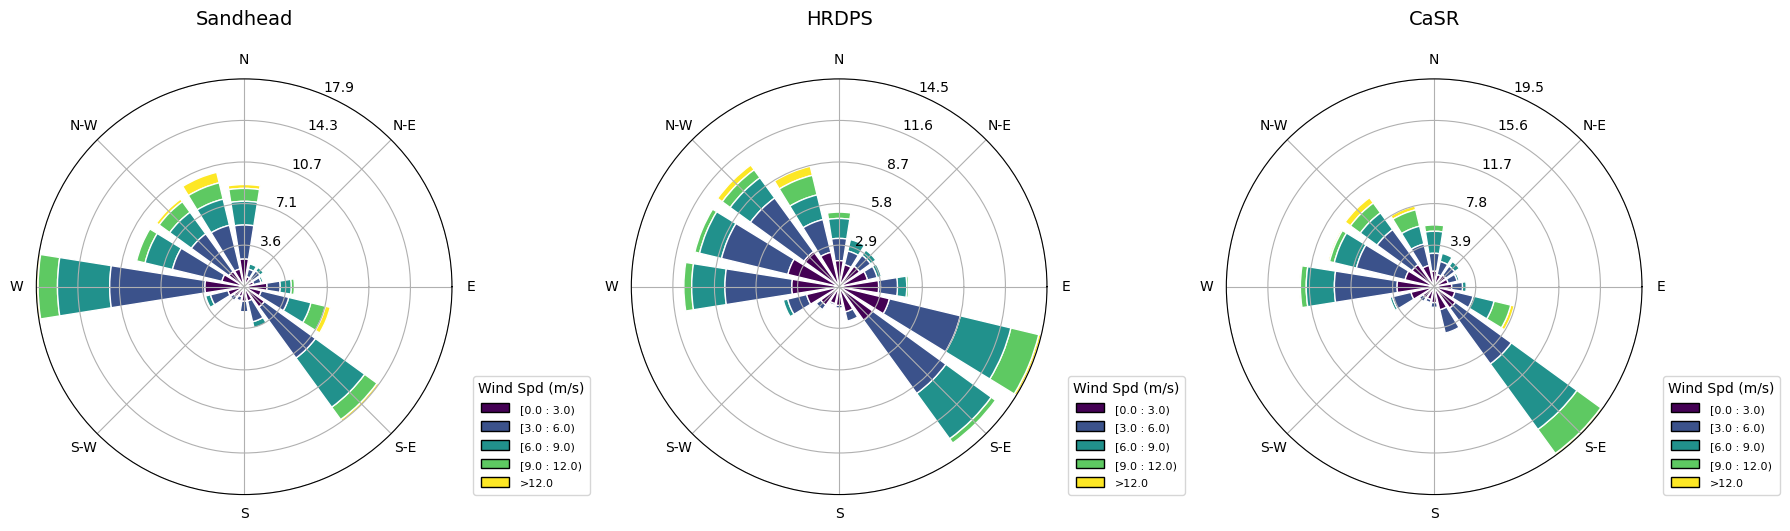

/tmp/ipykernel_2079034/353496020.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
/tmp/ipykernel_2079034/353496020.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
/tmp/ipykernel_2079034/353496020.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()


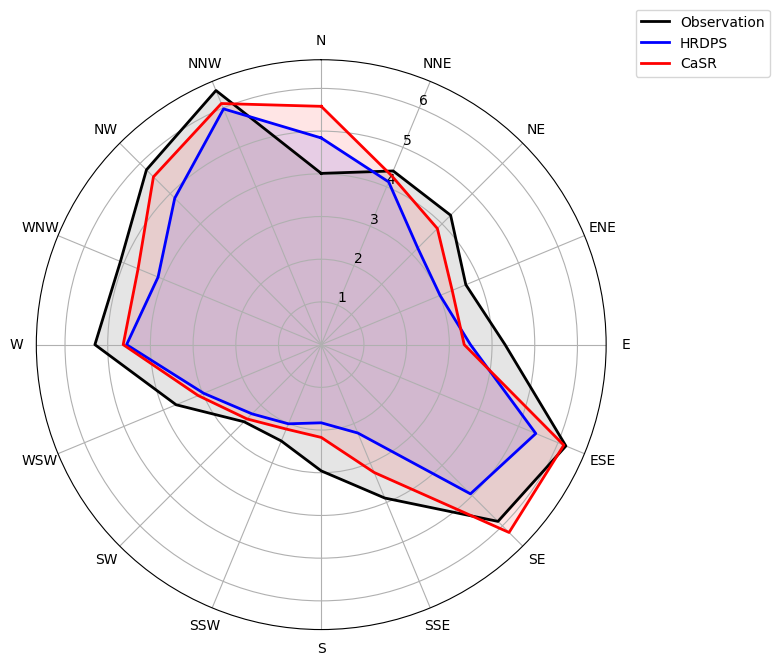

In [5]:
# Rose and Mean Speed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

df = pd.read_csv('/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2018/wind_comparison_2018.csv', index_col='Time_UTC', parse_dates=True)

# Wind Rose, Blowing Towards

fig = plt.figure(figsize=(18, 6))

def plot_windrose(fig_obj, pos, spd, direct, title):
    valid_idx = ~np.isnan(spd) & ~np.isnan(direct)
    spd_valid = spd[valid_idx]
    dir_valid = direct[valid_idx]
    
    ax = fig_obj.add_subplot(1, 3, pos, projection="windrose")
    ax.bar(dir_valid, spd_valid, normed=True, opening=0.8, edgecolor='white', bins=np.arange(0, 15, 3))
    ax.set_title(title, pad=20, fontsize=14)
    ax.set_legend(title="Wind Spd (m/s)", loc=(1.05, 0))

plot_windrose(fig, 1, df['Obs_Spd_ms'], df['Obs_Dir_deg'], "Sandhead")
plot_windrose(fig, 2, df['High_Spd_ms'], df['High_Dir_deg'], "HRDPS")
plot_windrose(fig, 3, df['Low_Spd_ms'], df['Low_Dir_deg'], "CaSR")

plt.tight_layout()
# plt.savefig('Wind_Roses_Comparison.png', dpi=300)
plt.show()


# Polygon, Blowing Towards

bins = np.arange(-11.25, 360, 22.5)
labels = np.arange(0, 360, 22.5)

def categorize_direction(d):
    cat = pd.cut(d % 360, bins=bins, labels=labels, right=False)
    cat = cat.fillna(0.0)
    return cat

df['Obs_Bin'] = categorize_direction(df['Obs_Dir_deg'])
df['High_Bin'] = categorize_direction(df['High_Dir_deg'])
df['Low_Bin'] = categorize_direction(df['Low_Dir_deg'])

obs_mean = df.groupby('Obs_Bin')['Obs_Spd_ms'].mean()
high_mean = df.groupby('High_Bin')['High_Spd_ms'].mean()
low_mean = df.groupby('Low_Bin')['Low_Spd_ms'].mean()

angles = np.deg2rad(labels)
angles_closed = np.append(angles, angles[0])
obs_closed = np.append(obs_mean.values, obs_mean.values[0])
high_closed = np.append(high_mean.values, high_mean.values[0])
low_closed = np.append(low_mean.values, low_mean.values[0])

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.plot(angles_closed, obs_closed, label='Observation', linewidth=2, color='black')
ax2.fill(angles_closed, obs_closed, color='black', alpha=0.1)

ax2.plot(angles_closed, high_closed, label='HRDPS', linewidth=2, color='blue')
ax2.fill(angles_closed, high_closed, color='blue', alpha=0.1)

ax2.plot(angles_closed, low_closed, label='CaSR', linewidth=2, color='red')
ax2.fill(angles_closed, low_closed, color='red', alpha=0.1)



direction_names = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
ax2.set_xticks(angles)
ax2.set_xticklabels(direction_names)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('Wind_Speed_Polygon_Comparison_TO.png', dpi=300)
plt.show()

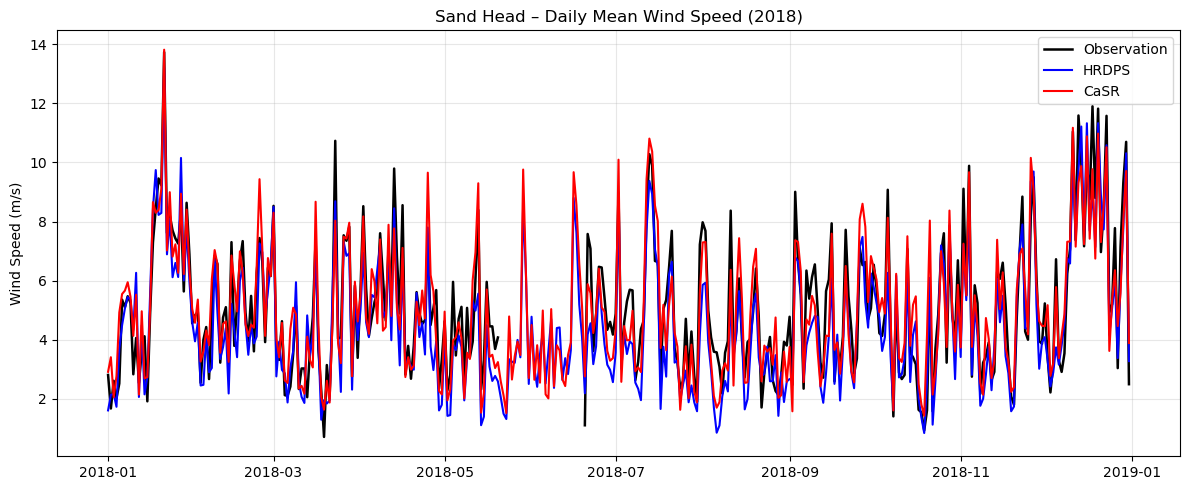

In [7]:
# Time Series (all year)

import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv(
    '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_SandHead/Data_2018/wind_comparison_2018.csv',
    index_col='Time_UTC',
    parse_dates=True
)

# 日平均
df_daily = df.resample('1D').mean()

# 绘图
plt.figure(figsize=(12, 5))

plt.plot(df_daily.index, df_daily['Obs_Spd_ms'],
         label='Observation', color='black', linewidth=1.8)

plt.plot(df_daily.index, df_daily['High_Spd_ms'],
         label='HRDPS', color='blue', linewidth=1.5)

plt.plot(df_daily.index, df_daily['Low_Spd_ms'],
         label='CaSR', color='red', linewidth=1.5)

plt.ylabel('Wind Speed (m/s)')
plt.title('Sand Head – Daily Mean Wind Speed (2018)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

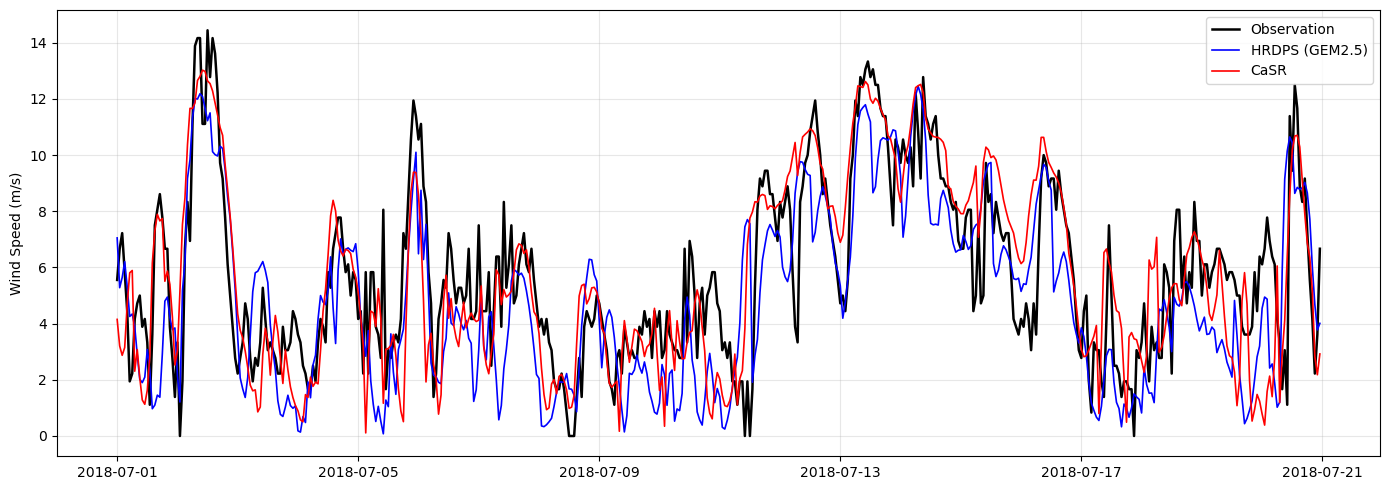

In [8]:
# Time Series (storm)

# July 1–20 
df_july = df.loc['2018-07-01':'2018-07-20']

plt.figure(figsize=(14, 5))

plt.plot(df_july.index, df_july['Obs_Spd_ms'],
         label='Observation', color='black', linewidth=1.8)

plt.plot(df_july.index, df_july['High_Spd_ms'],
         label='HRDPS (GEM2.5)', color='blue', linewidth=1.2)

plt.plot(df_july.index, df_july['Low_Spd_ms'],
         label='CaSR', color='red', linewidth=1.2)

plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()